<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day03/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
(20640, 9)

LINEAR REGRESSION
MAE: 0.5332001304956553
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R2: 0.5757877060324508

RANDOM FOREST
MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R2: 0.8051230593157366
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    

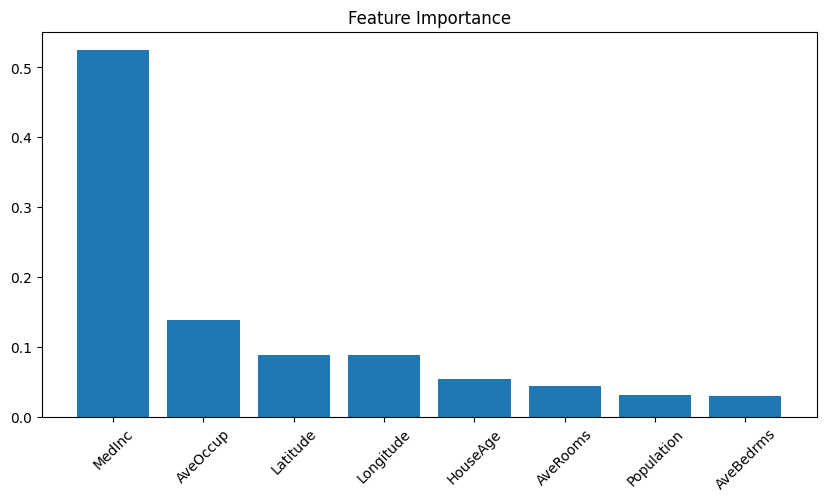

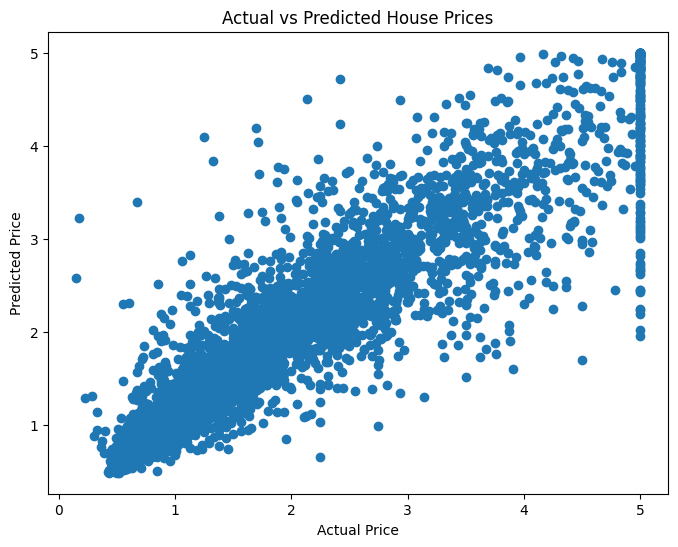

In [1]:
# =====================================
# DAY03 - HOUSE PRICE PREDICTION
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================
# LOAD DATASET
# =====================================

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['Price'] = housing.target

print(df.head())

print(df.shape)

# =====================================
# FEATURES AND TARGET
# =====================================

X = df.drop('Price', axis=1)

y = df['Price']

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# LINEAR REGRESSION
# =====================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLINEAR REGRESSION")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("MSE:",
      mean_squared_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2:",
      r2_score(y_test, lr_pred))

# =====================================
# RANDOM FOREST REGRESSOR
# =====================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRANDOM FOREST")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2:",
      r2_score(y_test, rf_pred))

# =====================================
# FEATURE IMPORTANCE
# =====================================

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)

plt.title(
    "Feature Importance"
)

plt.show()

# =====================================
# ACTUAL VS PREDICTED
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()